# Problem 2: Clustering Task

## Data Preprocessing

In [235]:
# Importing the difference libraries, that will be of use in this task
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [236]:
# Uploading the dataset
df = pd.read_csv('Online_Shopping_Behavior.csv')

In [237]:
# A quick look if the rows and columnes aligned with what is mentioned in the task info
df.shape

(6000, 4)

In [238]:
# Overview of the different values under the features
df.describe()

,Session_Duration,Page_Views,Purchase_Amount,Bounce_Rate
count,6000.000000,5400.000000,6000.000000,6000.000000
mean,30.701845,9.937222,246.287883,50.270282
std,17.018221,5.433968,143.602106,28.890141
min,1.020000,1.000000,0.010000,0.010000
25%,15.900000,5.000000,124.612500,25.477500
50%,30.950000,10.000000,242.650000,51.055000
75%,45.455000,15.000000,371.820000,75.057500
max,60.000000,19.000000,499.930000,100.000000


In [239]:
# Checking for null-data
print(df.isnull().sum())

Session_Duration      0
Page_Views          600
Purchase_Amount       0
Bounce_Rate           0
dtype: int64


In [243]:
# Making a copy of the original df
df_updated = df.copy()

# Converting the dataframe to an array
X = df.iloc[:, :].values
print(X)

[[ 16.43  19.   280.38  35.13]
 [ 39.21    nan 170.69  25.55]
 [  5.11   2.   304.08  77.02]
 ...
 [ 40.27    nan 330.98  35.86]
 [ 18.13  12.   448.65  83.94]
 [ 39.68   9.   275.88  88.11]]


In [244]:
# Swapping the nan values with mean values of the specific column (Page View)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

# A check to see if the action has been done correctly
print(X)

[[ 16.43        19.         280.38        35.13      ]
 [ 39.21         9.93722222 170.69        25.55      ]
 [  5.11         2.         304.08        77.02      ]
 ...
 [ 40.27         9.93722222 330.98        35.86      ]
 [ 18.13        12.         448.65        83.94      ]
 [ 39.68         9.         275.88        88.11      ]]


In [245]:
# Converting the array back to values in a dataframe
df_updated.iloc[:, :] = X
print(df_updated)

      Session_Duration  Page_Views  Purchase_Amount  Bounce_Rate
0                16.43   19.000000           280.38        35.13
1                39.21    9.937222           170.69        25.55
2                 5.11    2.000000           304.08        77.02
3                17.40    8.000000           295.39        51.87
4                 2.29   15.000000           244.86        59.65
...                ...         ...              ...          ...
5995             22.56    7.000000            37.08        42.15
5996             34.80   12.000000            10.86         7.84
5997             40.27    9.937222           330.98        35.86
5998             18.13   12.000000           448.65        83.94
5999             39.68    9.000000           275.88        88.11

[6000 rows x 4 columns]


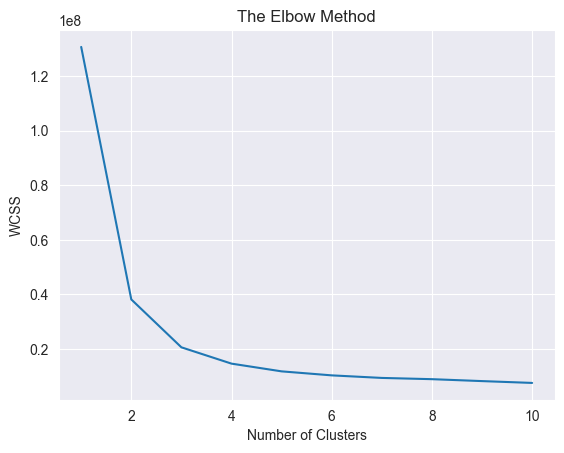

In [227]:
# The Elbow Method, to find the optimal amount of clusters to use
from sklearn.cluster import KMeans

# Within-Cluster Sum Squares - Looks at the distance between each point and the centroid of its cluster and, you square that distance.
wcss = []

# A loop that goes through 1-10 clusters, to then show where the WCSS starts to decrease at a slower rate, indicating the best cluster count.
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_updated)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Shows us the appropriate number of clusters is 3.

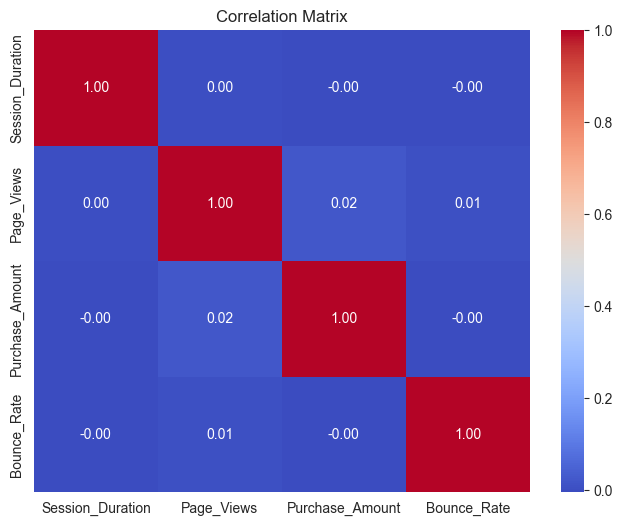

In [228]:
# With the amount of features we wanted to check for the best pairing.
correlation_matrix = df_updated.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [193]:
# Standardize or Normalize the data
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler_standard = StandardScaler()

# Pairing 1
features_1 = ['Page_Views', 'Purchase_Amount']
X_normalized_1 = scaler.fit_transform(df[features_1])
df_normalized_1 = pd.DataFrame(X_normalized_1, columns=features_1)

# Pairing 2
features_2 = ['Session_Duration', 'Purchase_Amount']
X_standardized_2 = scaler_standard.fit_transform(df[features_2])
df_standardized_2 = pd.DataFrame(X_standardized_2, columns=features_2)

# Pairing 3
features_3 = ['Page_Views', 'Bounce_Rate']
X_normalized_3 = scaler.fit_transform(df[features_3])
df_normalized_3 = pd.DataFrame(X_normalized_3, columns=features_3)

# Pairing 4
features_4 = ['Session_Duration', 'Bounce_Rate']
X_standardized_4 = scaler_standard.fit_transform(df[features_4])
df_standardized_4 = pd.DataFrame(X_standardized_4, columns=features_4)


## Model Building

In [203]:
# Next step is using the clustering algorithm - KMeans

from sklearn.cluster import KMeans

# Naming the different pairings
pairings = {
    "Pairing 1": df_normalized_1,
    "Pairing 2": df_standardized_2,
    "Pairing 3": df_normalized_3,
    "Pairing 4": df_standardized_4
}

# Result of the Elbow Method
optimal_clusters = 3

# A loop that goes through the data and assign each data point to a cluster.
for name, df_updated in pairings.items():
    kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42)
    clusters = kmeans.fit_predict(df_updated)
    
    df_updated['Cluster'] = clusters
    
    # Print or visualize the results
    print(df_updated.head())
    print("\n")


   Page_Views  Purchase_Amount  Cluster
0    1.000000         0.560830        0
1    0.496512         0.341415        0
2    0.055556         0.608237        1
3    0.388889         0.590855        2
4    0.777778         0.489778        0


   Session_Duration  Purchase_Amount  Cluster
0         -0.838691         0.237427        2
1          0.499986        -0.526484        0
2         -1.503916         0.402480        2
3         -0.781689         0.341960        2
4         -1.669635        -0.009944        2


   Page_Views  Bounce_Rate  Cluster
0    1.000000     0.351235        0
1    0.496512     0.255426        1
2    0.055556     0.770177        2
3    0.388889     0.518652        2
4    0.777778     0.596460        0


   Session_Duration  Bounce_Rate  Cluster
0         -0.838691    -0.524108        1
1          0.499986    -0.855736        1
2         -1.503916     0.925989        2
3         -0.781689     0.055377        2
4         -1.669635     0.324696        2


# Analyse
## Visualize

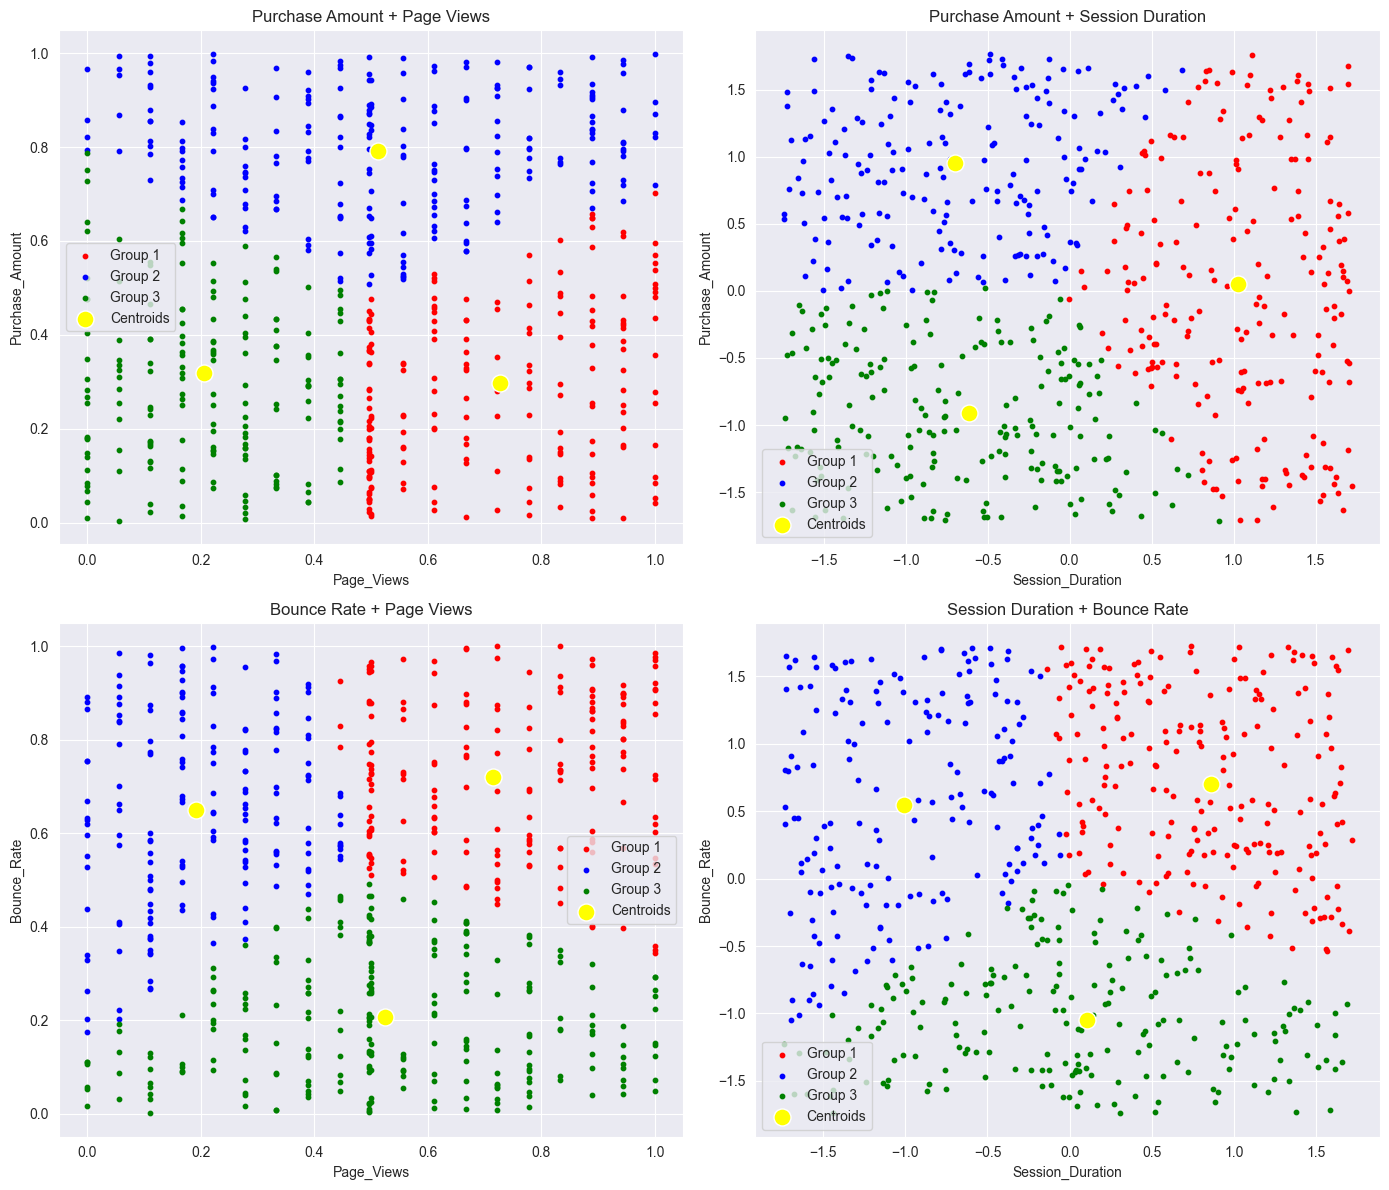

In [205]:
# Define all pairings and their details
pairings = {
    "Purchase Amount + Page Views": (df_normalized_1, ['Page_Views', 'Purchase_Amount']),
    "Purchase Amount + Session Duration": (df_standardized_2, ['Session_Duration', 'Purchase_Amount']),
    "Bounce Rate + Page Views": (df_normalized_3, ['Page_Views', 'Bounce_Rate']),
    "Session Duration + Bounce Rate": (df_standardized_4, ['Session_Duration', 'Bounce_Rate'])
}

# Set up the figure and axes for 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Loop through each pairing and plot on the corresponding axis
for i, (title, (df_updated, features)) in enumerate(pairings.items()):
    kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42)
    clusters = kmeans.fit_predict(df_updated.iloc[:, :2].values)
    df_updated['Cluster'] = clusters

    # Sampling 10% of the data
    sample_indices = np.random.choice(df_updated.shape[0], size=int(0.1 * df_updated.shape[0]), replace=False)
    sample_data = df_updated.iloc[sample_indices]

    # Labeling the different clusters into groups    
    group_labels = ['Group 1', 'Group 2', 'Group 3']

    # Coloring the different data points
    for j, color in enumerate(['red', 'blue', 'green']):
        axes[i].scatter(sample_data[sample_data['Cluster'] == j][features[0]],
                    sample_data[sample_data['Cluster'] == j][features[1]],
                    s=10, c=color, label=group_labels[j])
    
    # Adding the Centroids
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=150, c='yellow', edgecolors='white', label='Centroids')
    
    # Labeling the different axes
    axes[i].set_title(title)
    axes[i].set_xlabel(features[0])
    axes[i].set_ylabel(features[1])
    axes[i].legend()

plt.tight_layout()
plt.show()